In [1]:
import copy
import math
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

root_dir = os.path.abspath("..")
if root_dir not in sys.path:
    sys.path.append(root_dir)

from current_setpoints.models.machines import ieee_machine2_params, ieee_machine2, _build_cross_coupling
from current_setpoints.utils import NeuralFluxPredictor, load_aggregated_csv_data

torch.manual_seed(42)
np.random.seed(42)

In [2]:
AGGREGATED_FILE_PATH = "../data/aggregated_file_means.csv"
COLUMN_MAP = {c: c for c in ["omega", "id1", "iq1", "id3", "iq3", "ud1", "uq1", "ud3", "uq3", "torq"]}
INPUT_SIZE = 5
OUTPUT_SIZE = 1
TEST_SIZE = 0.15
RANDOM_STATE = 42
VAL_SIZE = 0.20
DEVICE = torch.device("cpu")

ACTIVATION = "gelu"
LR = 5e-3
WEIGHT_DECAY = 1e-5
EPOCHS = 15000
PATIENCE = 1000
VOLT_WEIGHT = 6.0  # fixed at the previously-established best value -- this sweep is about depth only

# 1, 2, and 3 hidden-layer architectures, spanning a comparable parameter
# range, to directly test whether extra depth helps on OUR measured dataset
# (as opposed to the supervisor's dense, noise-free FEM grid, where a
# single-hidden-layer net was reported to underfit).
ARCHITECTURES = [
    [12], [24], [32], [48],                    # 1 layer
    [24, 12], [32, 16], [48, 24], [24, 24],    # 2 layers
    [32, 16, 8], [48, 24, 12],                 # 3 layers
]
N_SEEDS = 3  # a few restarts per architecture -- small dataset, training is noisy

params = ieee_machine2_params()
R_stat = torch.from_numpy(params.R_stat).float().to(DEVICE)
L_stat = torch.from_numpy(params.L_stat).float().to(DEVICE)
flux_pm = torch.from_numpy(params.flux_pm).float().to(DEVICE)
J = torch.from_numpy(_build_cross_coupling(2)).float().to(DEVICE)
k_ = 5 * params.n_ppairs / 4.0

df = load_aggregated_csv_data(AGGREGATED_FILE_PATH, COLUMN_MAP)
X = df[["omega", "id1", "iq1", "id3", "iq3"]].to_numpy(dtype=np.float32)
volt = df[["ud1", "uq1", "ud3", "uq3"]].to_numpy(dtype=np.float32)
torq = df[["torq"]].to_numpy(dtype=np.float32)

X_trainval, X_test, volt_trainval, volt_test, torq_trainval, torq_test = train_test_split(
    X, volt, torq, test_size=TEST_SIZE, random_state=RANDOM_STATE
)
X_train, X_val, volt_train, volt_val, torq_train, torq_val = train_test_split(
    X_trainval, volt_trainval, torq_trainval, test_size=VAL_SIZE, random_state=RANDOM_STATE
)
print(f"train={len(X_train)}  val={len(X_val)}  test={len(X_test)}")

Loaded 174 valid data points from CSV.
train=117  val=30  test=27


In [3]:
def to_t(a):
    return torch.from_numpy(np.asarray(a, dtype=np.float32)).to(DEVICE)


scaler_X = StandardScaler()
X_train_norm = to_t(scaler_X.fit_transform(X_train))
X_val_norm = to_t(scaler_X.transform(X_val))
X_test_norm = to_t(scaler_X.transform(X_test))
SCALER_SCALE = scaler_X.scale_

i_train_t, i_val_t, i_test_t = to_t(X_train[:, 1:]), to_t(X_val[:, 1:]), to_t(X_test[:, 1:])
omega_train_t, omega_val_t, omega_test_t = to_t(X_train[:, :1]), to_t(X_val[:, :1]), to_t(X_test[:, :1])
volt_train_t, volt_val_t, volt_test_t = to_t(volt_train), to_t(volt_val), to_t(volt_test)
torq_train_t, torq_val_t, torq_test_t = to_t(torq_train), to_t(torq_val), to_t(torq_test)

var_v = volt_train_t.var()
var_t = torq_train_t.var()

In [4]:
def _gelu_deriv(z):
    return 0.5 * (1.0 + torch.erf(z / math.sqrt(2.0))) + z * torch.exp(-0.5 * z * z) / math.sqrt(2.0 * math.pi)


def _gelu_second_deriv(z):
    return (2.0 - z * z) * torch.exp(-0.5 * z * z) / math.sqrt(2.0 * math.pi)


def batched_grad_hessian(model, x_normed, scaler_scale):
    """Forward-mode 2nd-order propagation of the network's scalar output's
    gradient/Hessian w.r.t. current, for an arbitrary number of hidden
    layers -- same recursion used by machines.py's NeuralFlux and by
    flux_nn_trainer.ipynb."""
    N, d0 = x_normed.shape
    scale = torch.as_tensor(scaler_scale, dtype=torch.float32)
    grad_h = torch.eye(d0, dtype=torch.float32).unsqueeze(0).expand(N, d0, d0)
    hess_h = torch.zeros(N, d0, d0, d0, dtype=torch.float32)
    h = x_normed
    for layer in model.layers:
        W, b = layer.weight, layer.bias
        z = h @ W.T + b
        grad_z = torch.einsum("kp,npd->nkd", W, grad_h)
        hess_z = torch.einsum("kp,npqr->nkqr", W, hess_h)
        d_act = _gelu_deriv(z)
        d2_act = _gelu_second_deriv(z)
        h = torch.nn.functional.gelu(z)
        grad_h = d_act.unsqueeze(-1) * grad_z
        hess_h = d_act.unsqueeze(-1).unsqueeze(-1) * hess_z + d2_act.unsqueeze(-1).unsqueeze(-1) * torch.einsum(
            "nkp,nkq->nkpq", grad_z, grad_z
        )
    w_out = model.out_layer.weight.reshape(-1)
    grad_normed = torch.einsum("k,nkd->nd", w_out, grad_h)
    hess_normed = torch.einsum("k,nkpq->npq", w_out, hess_h)
    grad_x = grad_normed / scale
    grad_i = grad_x[:, 1:]
    hess_x = hess_normed / (scale.view(1, -1, 1) * scale.view(1, 1, -1))
    hess_i = hess_x[:, 1:, 1:]
    return grad_i, hess_i


def physics_loss(model, x_normed, i, omega, volt_meas, torq_meas):
    grad_i, hess_i = batched_grad_hessian(model, x_normed, SCALER_SCALE)
    flux_pred = flux_pm.unsqueeze(0) + i @ L_stat.T + grad_i
    L_batch = L_stat.unsqueeze(0) + hess_i
    JL_batch = torch.einsum("jl,nlk->njk", J, L_batch)
    LJt_batch = torch.einsum("npq,rq->npr", L_batch, J)
    v_pred = (
        i @ R_stat.T
        + omega * torch.einsum("njk,nk->nj", JL_batch, i)
        + omega * torch.einsum("jl,nl->nj", J, flux_pred)
    )
    loss_v = nn.functional.mse_loss(v_pred, volt_meas)
    A_batch = k_ * (JL_batch + LJt_batch)
    quad = torch.einsum("ni,nij,nj->n", i, A_batch, i).unsqueeze(1)
    b_pred = k_ * torch.einsum("jl,nl->nj", J, flux_pred)
    t_pred = quad + 2.0 * (b_pred * i).sum(dim=1, keepdim=True)
    loss_t = nn.functional.mse_loss(t_pred, torq_meas)
    return VOLT_WEIGHT * loss_v / var_v + loss_t / var_t, loss_v, loss_t

In [5]:
def train_one(hidden_sizes, seed):
    torch.manual_seed(seed)
    model = NeuralFluxPredictor(INPUT_SIZE, hidden_sizes, OUTPUT_SIZE, scaler_X, DEVICE, ACTIVATION).to(DEVICE)
    with torch.no_grad():
        model.out_layer.weight.mul_(1e-2)
        model.out_layer.bias.mul_(1e-2)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    best_val_loss = float("inf")
    best_weights = copy.deepcopy(model.state_dict())
    epochs_no_improve = 0
    for epoch in range(EPOCHS):
        model.train()
        optimizer.zero_grad()
        loss, _, _ = physics_loss(model, X_train_norm, i_train_t, omega_train_t, volt_train_t, torq_train_t)
        loss.backward()
        optimizer.step()
        model.eval()
        with torch.no_grad():
            val_loss, _, _ = physics_loss(model, X_val_norm, i_val_t, omega_val_t, volt_val_t, torq_val_t)
        val_loss_val = val_loss.item()
        if val_loss_val < best_val_loss - 1e-6:
            best_val_loss = val_loss_val
            best_weights = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= PATIENCE:
                break
    model.load_state_dict(best_weights)
    model.eval()
    with torch.no_grad():
        _, test_lv, test_lt = physics_loss(model, X_test_norm, i_test_t, omega_test_t, volt_test_t, torq_test_t)
    return test_lv.item() ** 0.5, test_lt.item() ** 0.5

In [6]:
results = []
for arch in ARCHITECTURES:
    runs = [train_one(arch, seed=1000 + s) for s in range(N_SEEDS)]
    best = min(runs, key=lambda r: r[1])  # best by torque RMSE, the harder/objective metric
    dims = [INPUT_SIZE] + list(arch) + [OUTPUT_SIZE]
    n_params = sum(a * b + b for a, b in zip(dims[:-1], dims[1:]))
    results.append({"arch": arch, "n_layers": len(arch), "n_params": n_params, "runs": runs,
                    "best_volt_rmse": best[0], "best_torq_rmse": best[1]})
    print(f"{str(arch):<16} n_params={n_params:<6} best_volt_rmse={best[0]:.4f} best_torq_rmse={best[1]:.4f}")

baseline = ieee_machine2()
v_pred, t_pred = [], []
for row_idx in range(len(X_test)):
    w = float(X_test[row_idx, 0])
    i_row = X_test[row_idx, 1:]
    t_pred.append(baseline.torque(w, i_row))
    v_pred.append(baseline.voltage_operator(w, i_row) @ i_row + baseline.bemf_dq(w, i_row))
v_pred, t_pred = np.array(v_pred), np.array(t_pred)
baseline_volt_rmse = np.sqrt(np.mean((volt_test - v_pred) ** 2))
baseline_torq_rmse = np.sqrt(np.mean((torq_test[:, 0] - t_pred) ** 2))
print(f"\nConstantFlux baseline (no NN): volt_rmse={baseline_volt_rmse:.4f}  torq_rmse={baseline_torq_rmse:.4f}")

[12]             n_params=85     best_volt_rmse=0.6367 best_torq_rmse=0.4600


[24]             n_params=169    best_volt_rmse=0.5780 best_torq_rmse=0.4970


[32]             n_params=225    best_volt_rmse=0.4802 best_torq_rmse=0.4986


[48]             n_params=337    best_volt_rmse=0.5952 best_torq_rmse=0.4698


[24, 12]         n_params=457    best_volt_rmse=0.7405 best_torq_rmse=0.4276


[32, 16]         n_params=737    best_volt_rmse=0.5720 best_torq_rmse=0.4852


[48, 24]         n_params=1489   best_volt_rmse=0.6490 best_torq_rmse=0.4306


[24, 24]         n_params=769    best_volt_rmse=0.6408 best_torq_rmse=0.5137


[32, 16, 8]      n_params=865    best_volt_rmse=0.6487 best_torq_rmse=0.5353


[48, 24, 12]     n_params=1777   best_volt_rmse=0.5695 best_torq_rmse=0.4764

ConstantFlux baseline (no NN): volt_rmse=0.5502  torq_rmse=0.8655


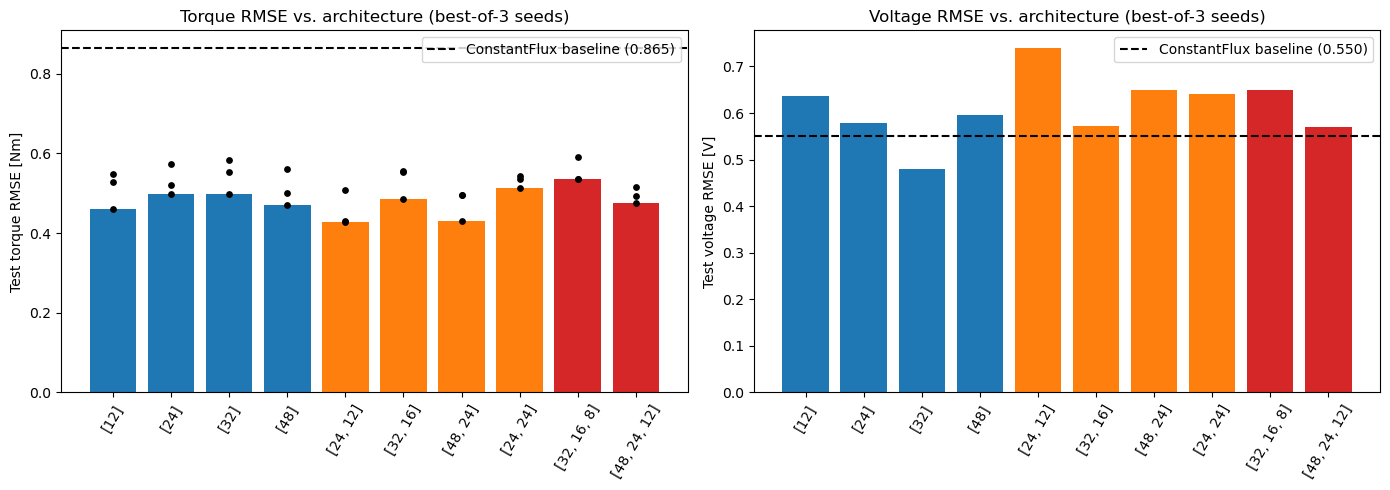

blue = 1 hidden layer, orange = 2 hidden layers, red = 3 hidden layers
black dots = individual seed runs (run-to-run spread within one architecture)


In [7]:
labels = [str(r["arch"]) for r in results]
torq_rmses = [r["best_torq_rmse"] for r in results]
volt_rmses = [r["best_volt_rmse"] for r in results]
colors = ["tab:blue" if r["n_layers"] == 1 else "tab:orange" if r["n_layers"] == 2 else "tab:red" for r in results]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(labels, torq_rmses, color=colors)
axes[0].axhline(baseline_torq_rmse, color="k", linestyle="--", label=f"ConstantFlux baseline ({baseline_torq_rmse:.3f})")
axes[0].set_ylabel("Test torque RMSE [Nm]")
axes[0].set_title("Torque RMSE vs. architecture (best-of-3 seeds)")
axes[0].tick_params(axis="x", rotation=60)
axes[0].legend()

for r in results:
    xs = [str(r["arch"])] * len(r["runs"])
    ys = [run[1] for run in r["runs"]]
    axes[0].scatter(xs, ys, color="black", s=15, zorder=3)

axes[1].bar(labels, volt_rmses, color=colors)
axes[1].axhline(baseline_volt_rmse, color="k", linestyle="--", label=f"ConstantFlux baseline ({baseline_volt_rmse:.3f})")
axes[1].set_ylabel("Test voltage RMSE [V]")
axes[1].set_title("Voltage RMSE vs. architecture (best-of-3 seeds)")
axes[1].tick_params(axis="x", rotation=60)
axes[1].legend()

fig.tight_layout()
plt.show()

print("blue = 1 hidden layer, orange = 2 hidden layers, red = 3 hidden layers")
print("black dots = individual seed runs (run-to-run spread within one architecture)")